# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU
!nvidia-smi

Sat Jan 31 18:01:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


2.9.0+cu126


## 1. What are 3 areas in industry where computer vision is currently being used?

In [ ]:
# 1. Automotive for autonomous vehicles
# 2. Security for facial recognition and anomaly detection
# 3. Agriculture for disease, pests and nutrient deficiencies

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [ ]:
# This occurs when a model fits very well to a specific dataset (the data it was trained on) but performs poorly with "new data"
# Essentially, the model "memorizes" instead of "learning"

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [1]:
# 1. Regularization (L1/L2)
"""
- Regularization adds a penalty term to the loss function to discourage overly complex models. The two most common types are:
- L1 Regularization (Lasso) adds the absolute values of weights to the loss function. This tends to push some weights all the way to zero, effectively performing feature selection by eliminating less important features.
- L2 Regularization (Ridge) adds the squared values of weights to the loss function. This discourages large weights but doesn't eliminate them entirely, spreading the weight values more evenly across features.
"""
# 2. Dropout (neural nets)
"""
Dropout is a regularization technique specifically designed for neural networks.
During training, it randomly "drops out" (sets to zero) a proportion of neurons in each layer on each training iteration.
For example, with a dropout rate of 0.5, each neuron has a 50% chance of being temporarily removed.
This prevents neurons from co-adapting too much and forces the network to learn more robust features that work even when some neurons are missing.
During inference (when making predictions), all neurons are active but their outputs are scaled appropriately.
Dropout effectively trains an ensemble of different network architectures, which helps prevent overfitting.
"""
# 3. Cross-validation
"""
Cross-validation is a technique for assessing how well a model will generalize to independent data.

The most common approach is k-fold cross-validation, which works like this:

Split your data into k equal-sized folds (commonly k=5 or k=10)
Train the model k times, each time using k-1 folds for training and the remaining fold for validation
Average the performance metrics across all k runs

This gives you a more reliable estimate of model performance than a single train-test split,
and it uses your data more efficiently since every data point gets used for both training and validation.
Cross-validation is particularly useful for hyperparameter tuning and model selection,
helping you choose the best model configuration before final testing.
"""

'\nCross-validation is a technique for assessing how well a model will generalize to independent data.\n\nThe most common approach is k-fold cross-validation, which works like this:\n\nSplit your data into k equal-sized folds (commonly k=5 or k=10)\nTrain the model k times, each time using k-1 folds for training and the remaining fold for validation\nAverage the performance metrics across all k runs\n\nThis gives you a more reliable estimate of model performance than a single train-test split,\nand it uses your data more efficiently since every data point gets used for both training and validation.\nCross-validation is particularly useful for hyperparameter tuning and model selection,\nhelping you choose the best model configuration before final testing.\n'

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
import torchvision
import torch
from torch import nn
from pathlib import Path

models_path = Path('models')
mnist_path = models_path / 'mnist'

mnist_path.mkdir(parents=True, exist_ok=True)

train_dataset = torchvision.datasets.MNIST(
    root=mnist_path,
    train=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root=mnist_path,
    train=False,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.74MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

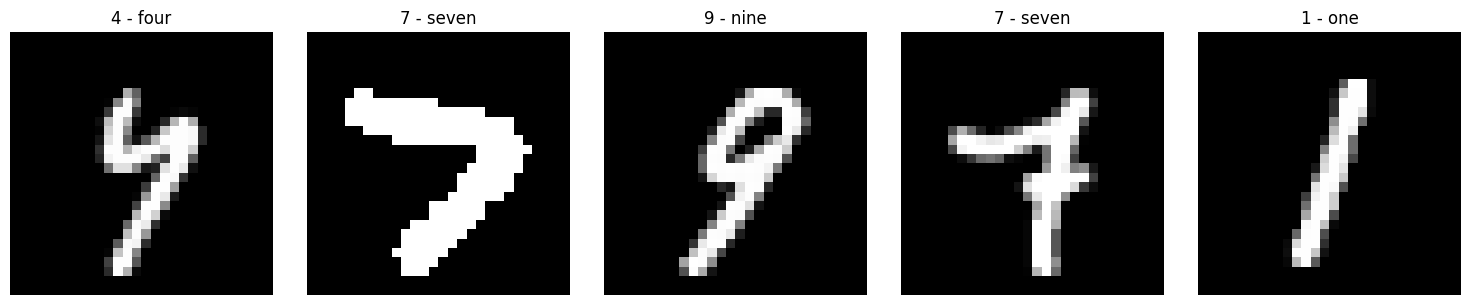

In [5]:
import random
import matplotlib.pyplot as plt

torch.manual_seed(42)

samples = random.sample(list(train_dataset), k=5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, (X_sample, target) in enumerate(samples):
  axes[i].imshow(X_sample.squeeze(), cmap='gray')
  axes[i].set_title(train_dataset.classes[target])
  axes[i].axis('off')

plt.tight_layout()
plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [7]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [8]:
class MNISTModel(nn.Module):
  def __init__(self, input_channels, output_channels, hidden_units):
    super().__init__()

    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(input_channels, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_channels)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.classifier(self.conv_layer_2(self.conv_layer_1(x)))


In [9]:
torch.manual_seed(42)

mnist_model = MNISTModel(
    input_channels=1, # Number of color channels
    output_channels=len(train_dataset.classes), # Number of classes
    hidden_units=32
).to(device)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [10]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.6 MB/s eta 0:00:00


In [11]:
from torchmetrics import Accuracy

In [12]:
from typing import Callable
from tqdm import tqdm

def train_step(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn: Accuracy,
    device: torch.device,
    epochs: int
):
  model = model.to(device)
  accuracy_fn = accuracy_fn.to(device)

  model.train()

  for epoch in tqdm(range(epochs)):
    train_loss = 0
    accuracy_fn.reset()

    for X, y in data_loader:
      X = X.to(device)
      y = y.to(device)

      y_logits = model(X)

      loss = loss_fn(y_logits, y)
      train_loss += loss.item()
      accuracy_fn.update(y_logits, y)

      optimizer.zero_grad()

      loss.backward()

      optimizer.step()

    average_loss = train_loss / len(data_loader)
    acc = accuracy_fn.compute().item()

    print(f'Epoch: {epoch} | Train Loss: {average_loss} | Train Accuracy: {acc * 100:.2f}%')


In [13]:
def eval_model(
    model: nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    accuracy_fn: Accuracy,
    device: torch.device
):
  """Returns a dictionary containing the result of the model predicting on dataloader"""
  loss, acc = 0, 0

  accuracy_fn = accuracy_fn.to(device)
  model = model.to(device)

  accuracy_fn.reset()

  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)

      loss += loss_fn(y_logits, y).item()
      accuracy_fn.update(y_logits, y)

  loss /= len(data_loader)
  acc = accuracy_fn.compute()

  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_accuracy": acc.item()
  }

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=mnist_model.parameters(), lr=0.01)
accuracy_fn = Accuracy('multiclass', num_classes=len(train_dataset.classes))

train_step(
    mnist_model,
    train_dataloader,
    loss_fn,
    optimizer,
    accuracy_fn,
    device,
    epochs=5
)

 20%|██        | 1/5 [00:12<00:48, 12.21s/it]

Epoch: 0 | Train Loss: 0.8226465828930338 | Train Accuracy: 72.18%


 40%|████      | 2/5 [00:23<00:34, 11.48s/it]

Epoch: 1 | Train Loss: 0.1090624622726192 | Train Accuracy: 96.71%


 60%|██████    | 3/5 [00:34<00:22, 11.29s/it]

Epoch: 2 | Train Loss: 0.07552176398038864 | Train Accuracy: 97.69%


 80%|████████  | 4/5 [00:45<00:11, 11.20s/it]

Epoch: 3 | Train Loss: 0.06205166690675542 | Train Accuracy: 98.08%


100%|██████████| 5/5 [00:56<00:00, 11.27s/it]

Epoch: 4 | Train Loss: 0.05301292104880946 | Train Accuracy: 98.38%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

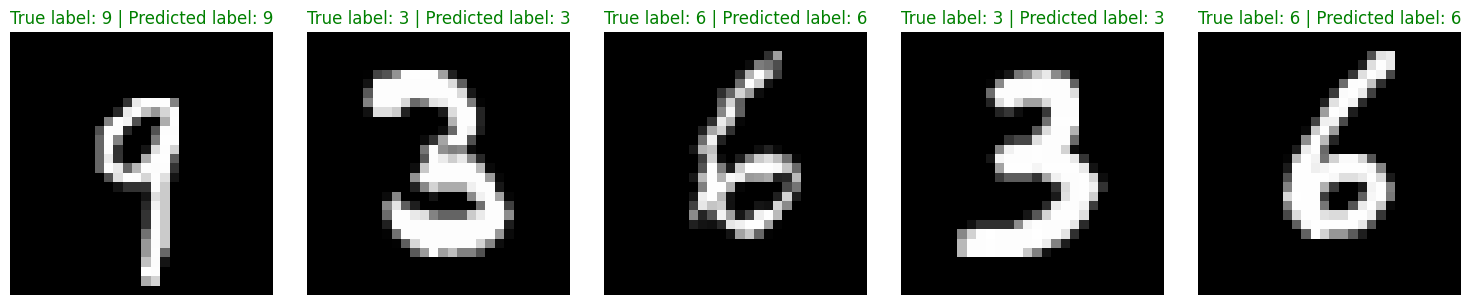

In [18]:
samples = random.sample(list(test_dataset), k=5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

mnist_model.eval()
with torch.inference_mode():
  for i, (image, label) in enumerate(samples):
    image = image.to(device)
    y_logits = mnist_model(image.unsqueeze(dim=0))
    y_probs = torch.softmax(y_logits, dim=1)
    y_preds = torch.argmax(y_probs, dim=1).item()

    axes[i].imshow(image.squeeze().cpu(), cmap='gray')
    axes[i].set_title(f"True label: {label} | Predicted label: {y_preds}", color='red' if y_preds != label else 'green')
    axes[i].axis(False)

plt.tight_layout()
plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [19]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

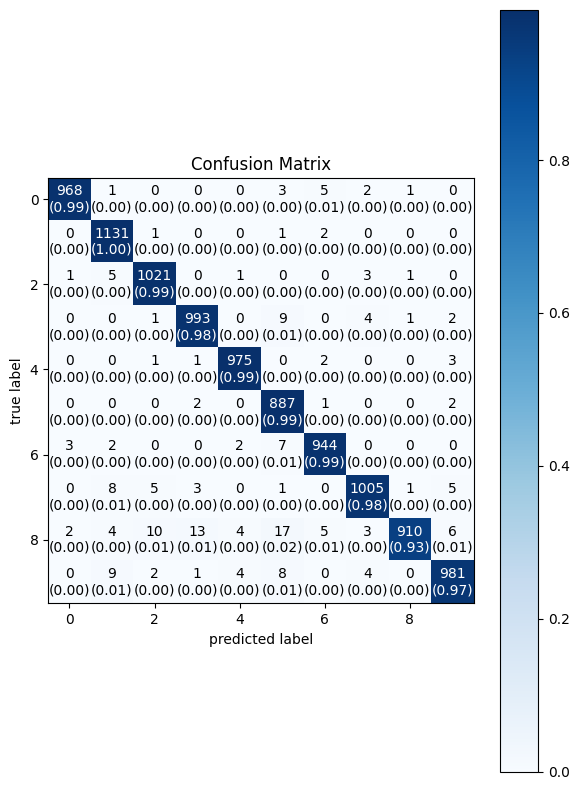

In [51]:
classes_names = train_dataset.classes

all_images = []
all_predictions = []
all_targets = []

with torch.inference_mode():
  mnist_model.eval()
  for X, y in test_dataloader:
    X = X.to(device)
    y = y.to(device)
    predictions_logits = mnist_model(X)
    predictions_probs = torch.softmax(predictions_logits, dim=1)
    predictions = torch.argmax(predictions_probs, dim=1)

    all_predictions.append(predictions.cpu())
    all_targets.append(y.cpu())
    all_images.append(X.cpu())

all_predictions = torch.cat(all_predictions, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_images = torch.cat(all_images, dim=0)

conf_mat = ConfusionMatrix(
    task='multiclass',
    num_classes=len(classes_names)
)

cm = conf_mat(all_predictions, all_targets)
cm_numpy = cm.numpy()

plot_confusion_matrix(
    conf_mat=cm_numpy,
    show_absolute=True,
    show_normed=True,
    colorbar=True,
    figsize=(6, 8)
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [52]:
torch.manual_seed(42)
rand_tensor = torch.randn(size=[1, 3, 64, 64])

conv_output = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(3, 3))

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

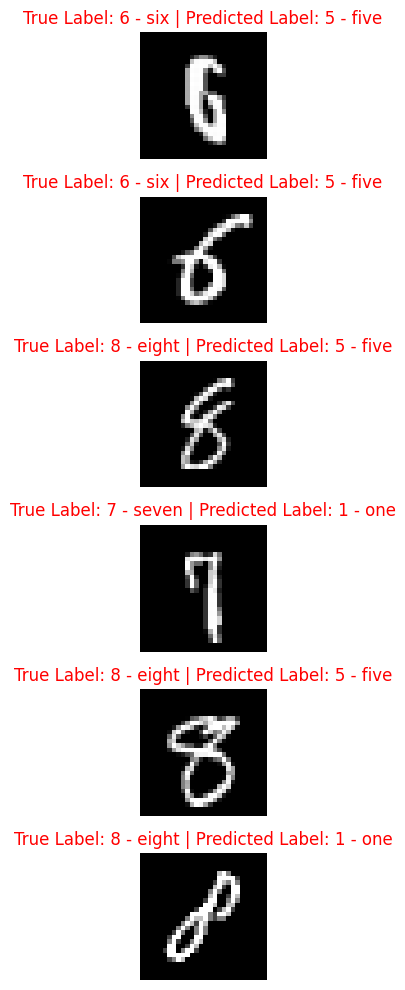

In [55]:
fig, axes = plt.subplots(6, 1, figsize=(8, 10))

axes_count = 0
for i in range(len(all_predictions)):
  if all_predictions[i] != all_targets[i]:
    axes[axes_count].imshow(all_images[i].squeeze().cpu(), cmap='gray')
    axes[axes_count].set_title(f"True Label: {classes_names[all_targets[i]]} | Predicted Label: {classes_names[all_predictions[i]]}", color="red")
    axes[axes_count].axis("off")
    axes_count += 1

    if axes_count == 6:
      break

plt.tight_layout()
plt.show()


# Task
Implement `train_step`, `test_step`, and `train` functions to train the `MNISTModel` on the MNIST dataset for 5 epochs on both CPU and GPU, measuring the elapsed time for each.

## Implement `train_step` function

### Subtask:
Define a function that performs a single training step, including forward pass, loss calculation, backward pass, and optimizer step.


**Reasoning**:
The subtask requires implementing the `train_step` function as described in the instructions. This function will handle a single training iteration, including forward pass, loss calculation, backward pass, and optimizer step.



In [56]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

## Implement `test_step` function

### Subtask:
Define a function that performs a single evaluation step on the test data, calculating loss and accuracy.


**Reasoning**:
The subtask is to implement the `test_step` function. This code block will define the `test_step` function according to the provided instructions, including setting the model to evaluation mode, performing a forward pass, calculating loss and accuracy, and returning the averaged metrics.



In [57]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference mode
    with torch.inference_mode():
        # Loop through data loader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy metric across all batches
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

**Reasoning**:
Now that `train_step` and `test_step` functions are defined, the next logical step is to implement the main `train` function. This function will coordinate the training and evaluation over multiple epochs, using the previously defined helper functions, and track the training process.



In [58]:
from tqdm.auto import tqdm
import time

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device):
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                         dataloader=test_dataloader,
                                         loss_fn=loss_fn,
                                         device=device)

        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the filled results array
    return results

**Reasoning**:
With the `train_step`, `test_step`, and `train` functions now defined, the next step is to instantiate the `MNISTModel` and prepare the optimizer and loss function. Then, we will train the model on the CPU and measure its performance, including the training time. This directly addresses the main task of training the model on the CPU.



In [60]:
torch.manual_seed(42)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer_cpu = torch.optim.SGD(mnist_model.parameters(), lr=0.1)

# Train the model on CPU
print("Training model on CPU...")
start_time_cpu = time.perf_counter()
mnist_model_cpu = MNISTModel(
    input_channels=1, # Number of color channels
    output_channels=len(train_dataset.classes), # Number of classes
    hidden_units=32
).to(device)

# Reinitialize optimizer for the CPU model (since parameters are different)
optimizer_cpu = torch.optim.SGD(mnist_model_cpu.parameters(), lr=0.1)

cpu_results = train(model=mnist_model_cpu,
                    train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    optimizer=optimizer_cpu,
                    loss_fn=loss_fn,
                    epochs=5,
                    device=device)
end_time_cpu = time.perf_counter()
total_time_cpu = end_time_cpu - start_time_cpu
print(f"Total training time on CPU: {total_time_cpu:.3f} seconds")

Training model on CPU...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2092 | train_acc: 0.9315 | test_loss: 0.0508 | test_acc: 0.9833
Epoch: 2 | train_loss: 0.0538 | train_acc: 0.9839 | test_loss: 0.0392 | test_acc: 0.9874
Epoch: 3 | train_loss: 0.0389 | train_acc: 0.9882 | test_loss: 0.0434 | test_acc: 0.9842
Epoch: 4 | train_loss: 0.0319 | train_acc: 0.9900 | test_loss: 0.0312 | test_acc: 0.9890
Epoch: 5 | train_loss: 0.0263 | train_acc: 0.9919 | test_loss: 0.0312 | test_acc: 0.9897
Total training time on CPU: 67.025 seconds
